# Fake News Detection

### Importing Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#re = regular expression(Useful for searching the text in a document)
import re
#nltk => Natural Language toolkit
#corpus => body of the text
#Stop words are those words, that don't add much value to the text(a,an,the,what,where)
from nltk.corpus import stopwords
#PorterStemmer is used for stemming(Removes the prefix and suffix of the word and returns the root word for it)
from nltk.stem.porter import PorterStemmer
#TfidfVectorizer is used to convert the words into feature vectors(Numbers)
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
#Printing the stopwords in english
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

### Loading the dataset

### Loading the dataset

In [46]:
data = pd.read_csv("dataset.csv", on_bad_lines='skip')
data.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,1


In [47]:
#Shape of the dataset
data.shape

(21023, 5)

### Data Preprocessing

In [48]:
#Checking for missing values
data.isnull().sum()

,0
id,0
title,566
author,1974
text,39
label,0


In [49]:
#Handling missing values
#Replacing the missing values with empty strings
data = data.fillna('')

In [50]:
data.isnull().sum()

,0
id,0
title,0
author,0
text,0
label,0


In [51]:
# Merging the author name and news title to form the input
data['content'] = data["author"] + ' ' + data["title"]

In [52]:
data['content']

,content
0,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,Consortiumnews.com Why the Truth Might Get You...
3,Jessica Purkiss 15 Civilians Killed In Single ...
4,Howard Portnoy Iranian woman jailed for fictio...
...,...
21018,Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
21019,"Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma..."
21020,Michael J. de la Merced and Rachel Abrams Macy...
21021,"Alex Ansary NATO, Russia To Hold Parallel Exer..."


In [53]:
#To make predictions we will be using the content column as features and labels as targets
#Seperating the data and label
x = data.drop(columns = 'label',axis = 1)
y = data['label']

In [54]:
x.head()

,id,title,author,text,content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",Consortiumnews.com Why the Truth Might Get You...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,Jessica Purkiss 15 Civilians Killed In Single ...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,Howard Portnoy Iranian woman jailed for fictio...


In [55]:
y.head()

,label
0,1
1,0
2,1
3,1
4,1


### Stemming Procedure
#### Stemming is the process of reducing a word to its Root Word
##### Eg : actor, actress, acting ==> act

In [56]:
#Using Porter Stemmer
port_stem = PorterStemmer()

In [57]:
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

### Before Stemming

In [58]:
data['content'].head()

,content
0,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,Consortiumnews.com Why the Truth Might Get You...
3,Jessica Purkiss 15 Civilians Killed In Single ...
4,Howard Portnoy Iranian woman jailed for fictio...


### Stemming

In [59]:
data['content'] = data['content'].apply(stemming)

### After Stemming

In [60]:
print(data['content'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2                   consortiumnew com truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
21018    jerom hudson rapper trump poster child white s...
21019    benjamin hoffman n f l playoff schedul matchup...
21020    michael j de la merc rachel abram maci said re...
21021    alex ansari nato russia hold parallel exercis ...
21022                            david swanson keep f aliv
Name: content, Length: 21023, dtype: object


In [61]:
#Since text is huge, we are not using it as a feature
# Seperating the data and label
x = data['content'].values
y = data['label'].values

In [62]:
print(x)

['darrel lucu hous dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynn flynn hillari clinton big woman campu breitbart'
 'consortiumnew com truth might get fire' ...
 'michael j de la merc rachel abram maci said receiv takeov approach hudson bay new york time'
 'alex ansari nato russia hold parallel exercis balkan'
 'david swanson keep f aliv']


In [63]:
print(y)

[1 0 1 ... 0 1 1]


In [64]:
y.shape

(21023,)

In [65]:
x.shape

(21023,)

### Converting the text of content into numerical data

In [66]:
# converting the textual data to numerical data
vectorizer = TfidfVectorizer()
vectorizer.fit(x)

x = vectorizer.transform(x)

In [67]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 212943 stored elements and shape (21023, 17128)>
  Coords	Values
  (0, 267)	0.26994165871200826
  (0, 2483)	0.3678526838363767
  (0, 2959)	0.24688082702933972
  (0, 3600)	0.360099966865229
  (0, 3792)	0.26994165871200826
  (0, 4973)	0.23307062280838983
  (0, 7005)	0.21891649470519708
  (0, 7692)	0.2476290378510693
  (0, 8630)	0.2923777731573127
  (0, 8909)	0.36379988359988474
  (0, 13473)	0.2568667272994911
  (0, 15686)	0.2845051062676149
  (1, 1497)	0.29395013691239
  (1, 1894)	0.15522478271172335
  (1, 2223)	0.38292843594973736
  (1, 2813)	0.19079189942695113
  (1, 3568)	0.26268262485157284
  (1, 5503)	0.7147677343113726
  (1, 6816)	0.19023890002984825
  (1, 16799)	0.30062756593389334
  (2, 2943)	0.31767693366318545
  (2, 3103)	0.46193486922841925
  (2, 5389)	0.3861019269980936
  (2, 5968)	0.34712601441460983
  (2, 9620)	0.492695959008119
  :	:
  (21020, 3643)	0.2114143778382731
  (21020, 7042)	0.21817176790705042
  (21020

### Splitting our data into training and testing data

In [68]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2,stratify = y)
#Stratify makes sure that the proportion of real news vs fake news in the real data set is maintained in the train test split

In [69]:
print(y.shape,y_train.shape,y_test.shape)

(21023,) (16818,) (4205,)


### Logistic Regression Model

In [70]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

### Evaluation

In [71]:
# Model Prediction
pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, pred)
print("F1 Score:", f1)

Accuracy: 0.9807372175980975
Precision: 0.9711493718008376
Recall: 0.9909781576448243
F1 Score: 0.9809635722679201


In [81]:
# Classification Report
report = classification_report(y_test, pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2099
           1       0.97      0.99      0.98      2106

    accuracy                           0.98      4205
   macro avg       0.98      0.98      0.98      4205
weighted avg       0.98      0.98      0.98      4205



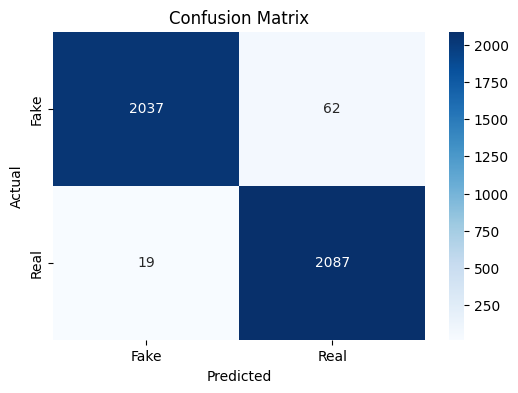

In [82]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

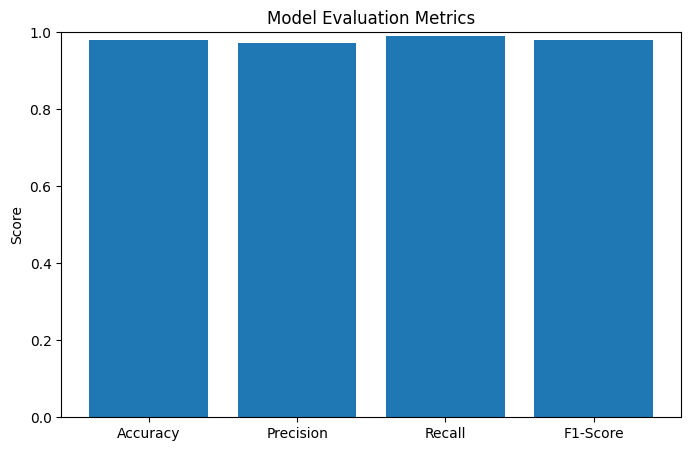

In [83]:
# Metrics Visualization

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.ylim(0,1)

plt.title('Model Evaluation Metrics')
plt.ylabel('Score')

plt.show()

### Making a predictive system

In [72]:
x_new = x_test[1]

prediction = model.predict(x_new)
print(prediction,y_test[1])
if prediction == 1:
    print("The news is true")
else:
    print("The news is fake")

[0] 0
The news is fake


In [73]:
import pickle

with open('fake_news_detect.pkl', 'wb') as f:
  pickle.dump(model, f)


In [74]:
with open('fake_news_detect.pkl', 'rb') as f:
  loaded_model = pickle.load(f)


In [75]:
def preprocess_text(text):  #creating a function for gradio
  text = text.lower()

  tokens = text.split()

  from nltk.corpus import stopwords
  stop_words = set(stopwords.words('english'))
  port_stem = PorterStemmer()
  def stemming(text):
    stemmed_content = re.sub('[^a-zA-Z]',' ',text)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

  preprocessed_text = ' '.join(tokens)
  return preprocessed_text


In [76]:
!pip install gradio scikit-learn nltk


In [77]:
import pickle

with open('/content/fake_news_detect.pkl', 'rb') as f:
  loaded_model = pickle.load(f)

In [78]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

def preprocess_text(text):
  text = text.lower()
  tokens = text.split()
  stop_words = set(stopwords.words('english'))
  stemmer = PorterStemmer()

  # Combine stemming and stop word removal:
  preprocessed_text = [stemmer.stem(word) for word in tokens if word not in stop_words]
  return ' '.join(preprocessed_text)


In [79]:
def predict_news(text):
  preprocessed_text = preprocess_text(text)
  prediction = loaded_model.predict([preprocessed_text])
  return f'Predicted: {prediction}'


In [80]:
import gradio as gr

def preprocess_text(text):
    text = text.lower()
    text = text.strip()
    return text

def predict_fake_news(text):
    score = 0.7
    return score

def fake_news_detector(text):
    preprocessed_text = preprocess_text(text)
    score = predict_fake_news(preprocessed_text)


    if score > 0.7:
        classification = "Fake"
    else:
        classification = "Real"


    confidence = 0.8

    output = (
        f"Classification: {classification}\n"
        f"Score: {score:.2f} (higher score indicates more likely fake news)\n"
    )
    if confidence:
        output += f"Confidence: {confidence:.2f}\n"
    return output


interface = gr.Interface(
    fake_news_detector,
    inputs="textbox",
    outputs="text",
    title="Fake News Detector",
    description="Enter some text to see if it's likely fake news. \n"
                "Output includes classification, score (higher indicates fake), "
                "and confidence level. \n",
    elem_id="fake-news-detector",
)

interface.launch()



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7133dd18dddf95f3fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
